In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("TelcoCustomer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [6]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype("float")


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
#coverted 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [15]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)

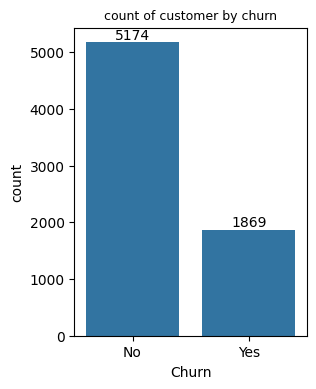

In [33]:
plt.figure(figsize=(3,4))
ax=sns.countplot(x="Churn",data=df)
ax.bar_label(ax.containers[0])
plt.title("count of customer by churn",fontsize=9)
plt.show()


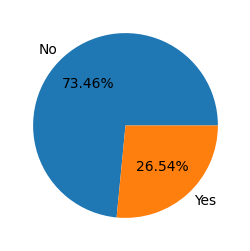

In [29]:
plt.figure(figsize=(3,3))
gp_by=df.groupby("Churn").agg({"Churn":"count"})
plt.pie(gp_by["Churn"],labels=gp_by.index,autopct="%1.2f%%")
plt.title("percentage of churned customers",fontsize=9)
plt.show()

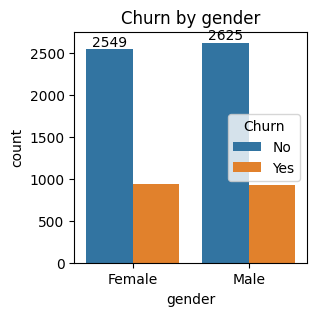

In [38]:
plt.figure(figsize=(3,3))
sns.countplot(data=df,x="gender",hue="Churn")

plt.title("Churn by gender")
plt.show()

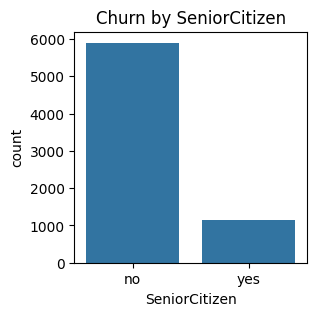

In [71]:
plt.figure(figsize=(3,3))
sns.countplot(data=df,x="SeniorCitizen")

plt.title("Churn by SeniorCitizen")
plt.show()

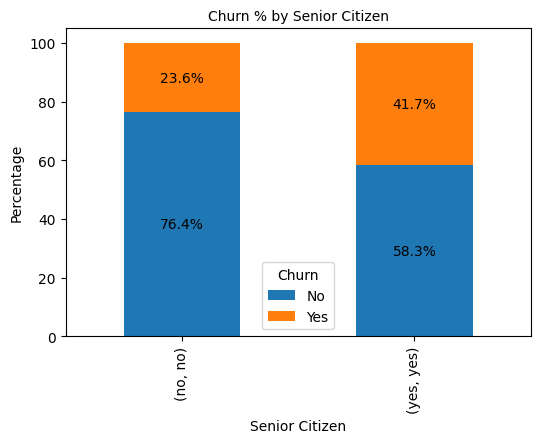

In [79]:
df["SeniorCitizen"] = df["SeniorCitizen"].replace({0: "No", 1: "Yes"})

data = (
    df.groupby(['SeniorCitizen', 'Churn'])
      .size()
      .groupby(level=0)
      .apply(lambda x: 100 * x / x.sum())
      .unstack()
)

ax = data.plot(kind='bar', stacked=True, figsize=(6,4))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title("Churn % by Senior Citizen",fontsize=10)
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=90)

plt.show()

In [ ]:
#comparative a greater percentage of people in senior citizen category have churned

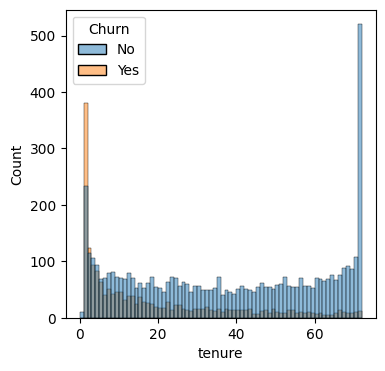

In [78]:
plt.figure(figsize=(4,4))
sns.histplot(data=df,x="tenure",hue="Churn",bins=72)
plt.show()

In [ ]:
#people who have used our services for a long time have stayed and people who have used our services(1 or 2 months)have churned out

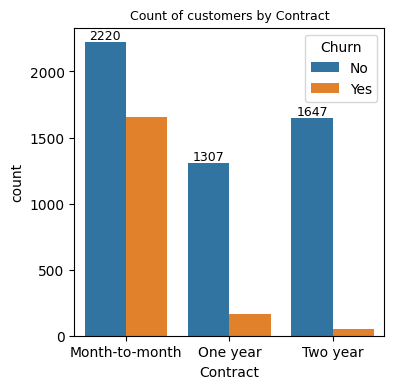

In [53]:
plt.figure(figsize=(4,4))
ax=sns.countplot(data=df,x="Contract",hue="Churn")
ax.bar_label(ax.containers[0],fontsize=9)
plt.title("Count of customers by Contract",fontsize=9)
plt.show()

In [ ]:
#people who have month-to-month contract are likely to churn then from those who have 1 or 2 years contract

In [55]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

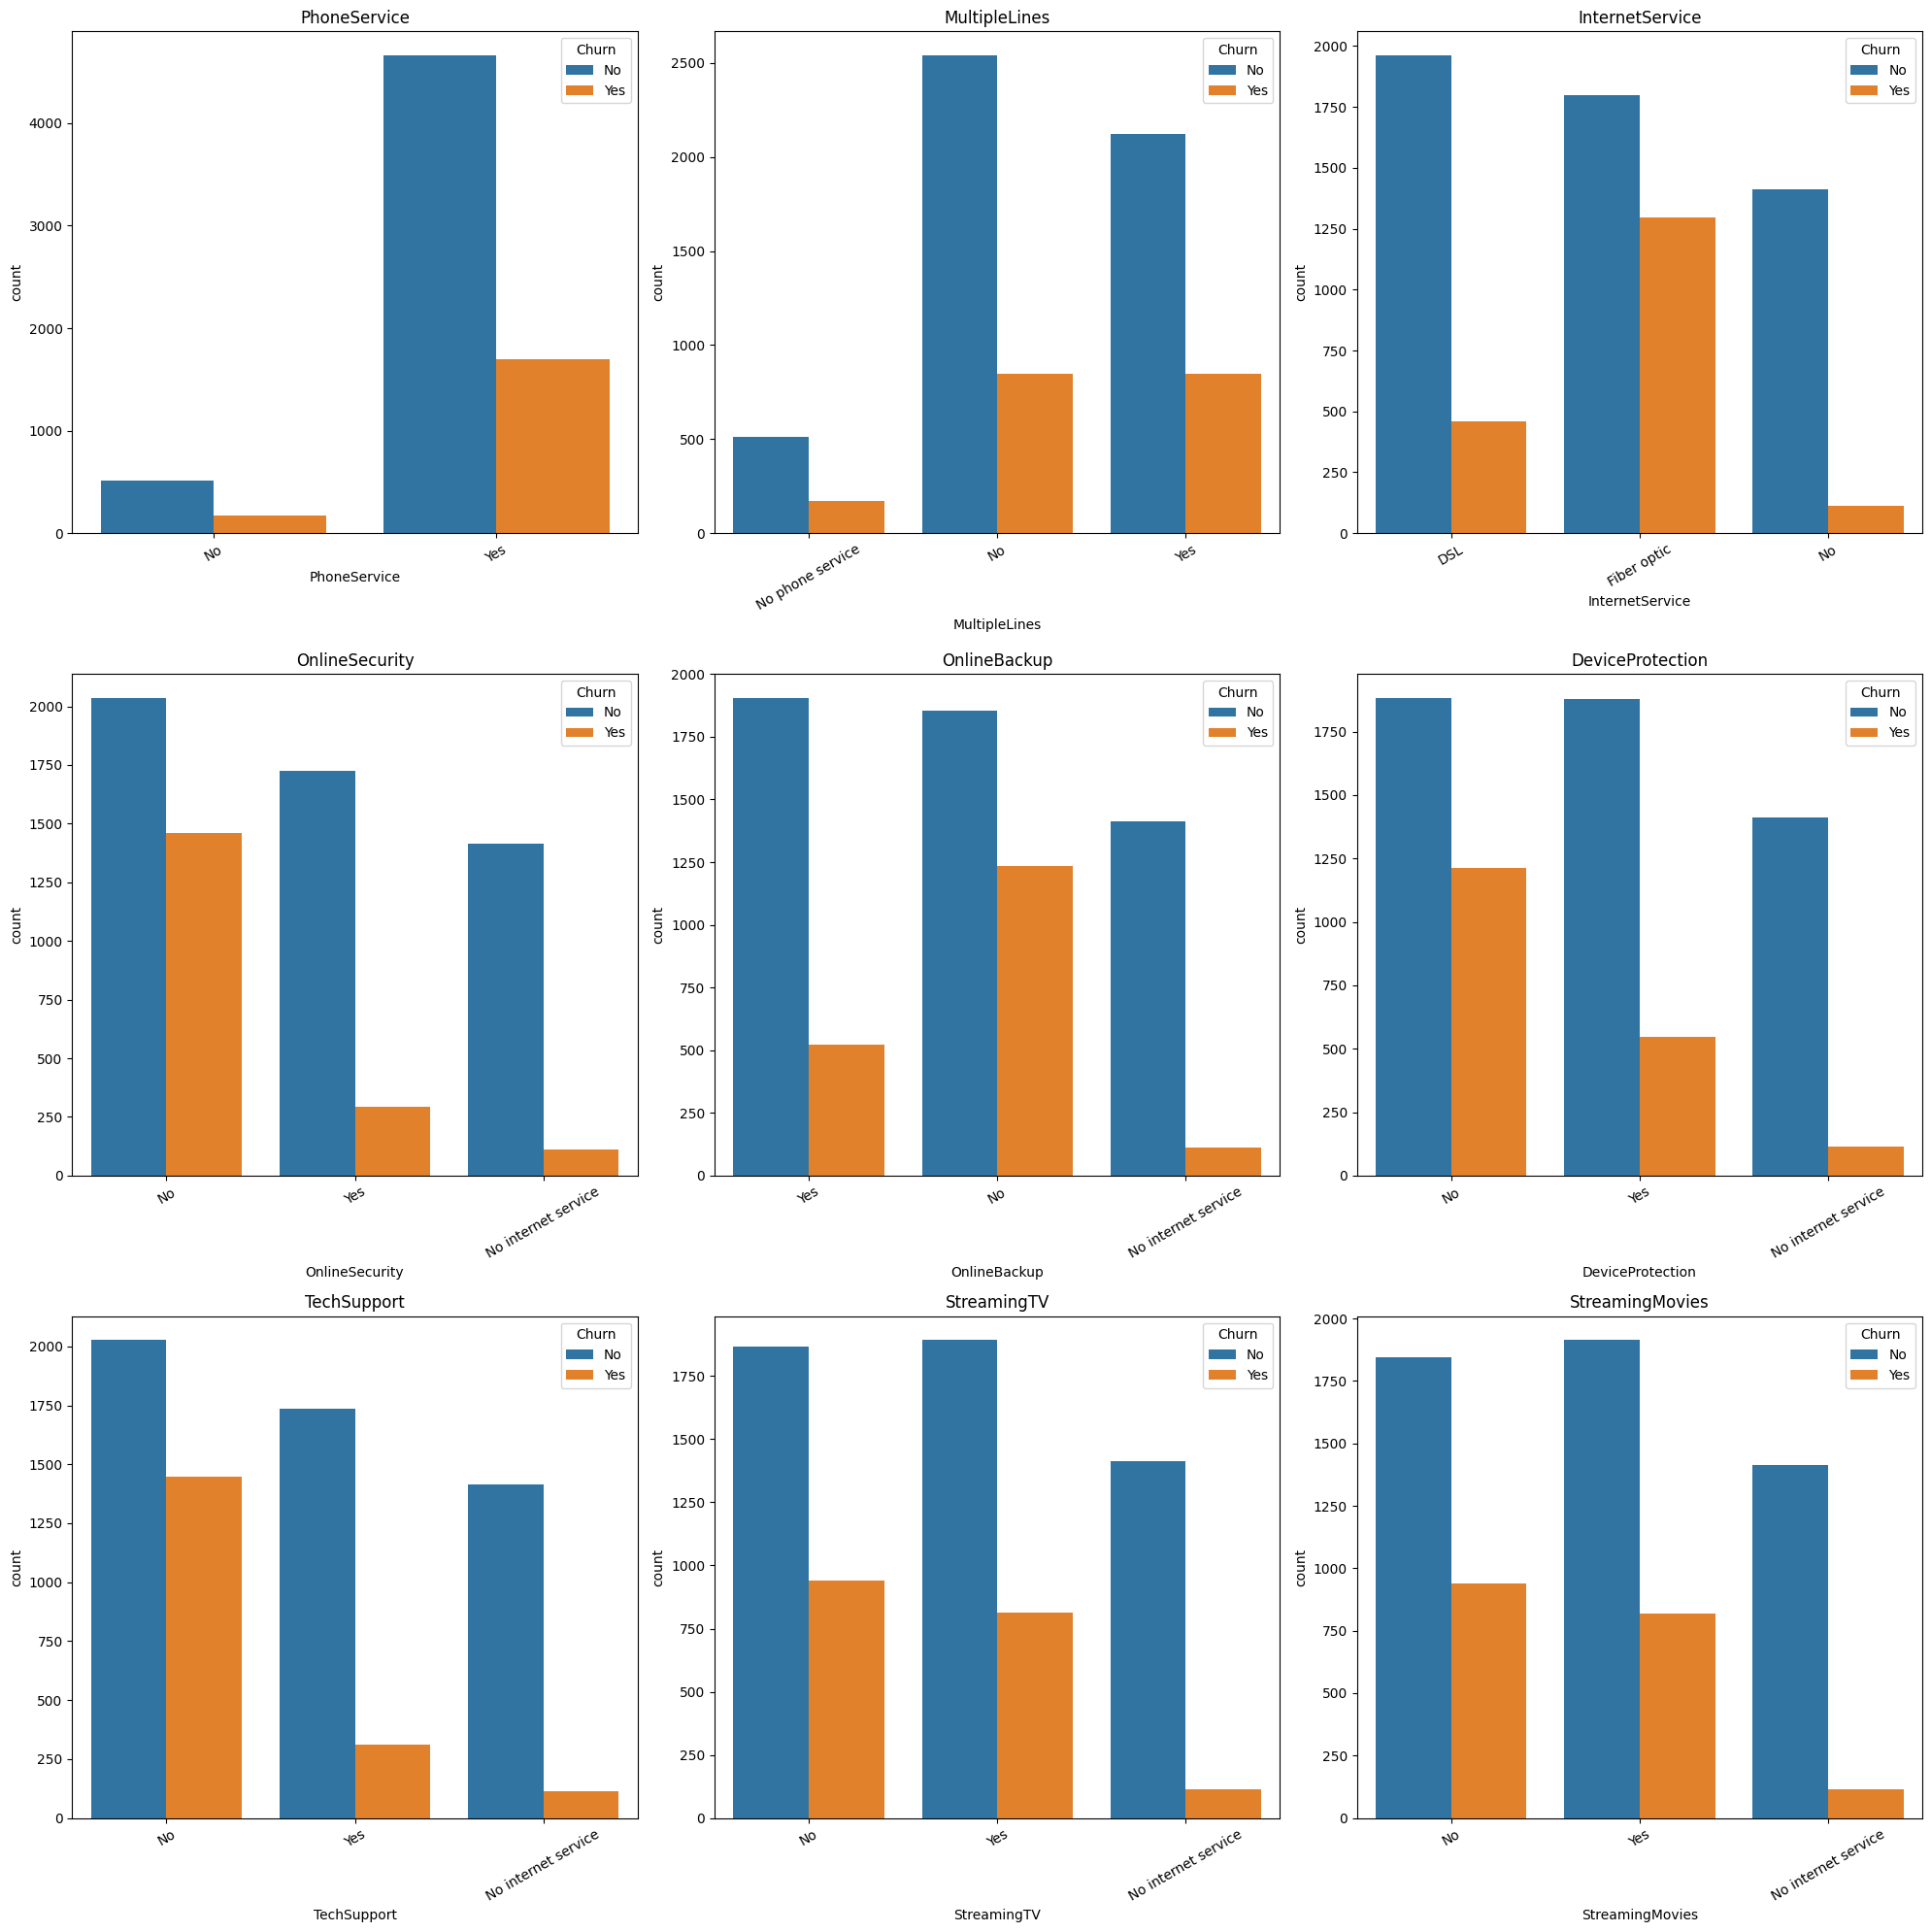

In [63]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

plt.figure(figsize=(20,20))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)  
    sns.countplot(x=col, data=df,hue="Churn")
    plt.title(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
#the majority of customers who do not churn tend to have services like PhoneService,InternetService & OnlineService enabled,and for services like TechSupport,StreamingTV,Online backup,churn rates are noticeably higher when thses services are not used or are unavailable

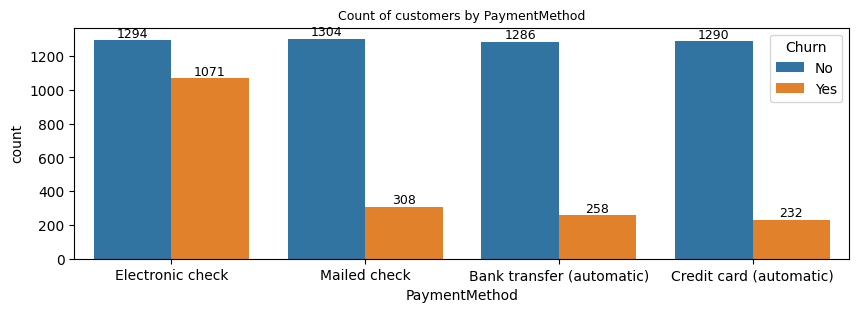

In [80]:
plt.figure(figsize=(10,3))
ax=sns.countplot(data=df,x="PaymentMethod",hue="Churn")
ax.bar_label(ax.containers[0],fontsize=9)
ax.bar_label(ax.containers[1],fontsize=9)
plt.title("Count of customers by PaymentMethod",fontsize=9)
plt.show()

In [ ]:
#customers is likely to churn when he is using electronic check as a pay